# CrisisNLP_R1

---

## A. Original

### CrisisNLP_labeled_data_crowdflower

- In this folder, each dataset contains more than 1,500 labeled tweets
- We used paid workers from the CrowdFlower crowdsourcing platform for the labeling
- At least three different workers were required to agree on a label to finalize a tweet label
- No worker was allowed to perform more than 200 tasks
- Detailed crowdsourcing tasks description is provided inside each folder
- No browsing to URLs in tweets.

#### Category---description:

1. Injured or dead people---Reports of casualties and/or injured people due to the crisis
2. Missing, trapped, or found people---Reports and/or questions about missing or found people
3. Displaced people and evacuations---People who have relocated due to the crisis, even for a short time (includes evacuations)
4. Infrastructure and utilities damage---Reports of damaged buildings, roads, bridges, or utilities/services interrupted or restored
5. Donation needs or offers or volunteering services---Reports of urgent needs or donations of shelter and/or supplies such as food, water, clothing, money, medical supplies or blood; and volunteering services
6. Caution and advice---Reports of warnings issued or lifted, guidance and tips
7. Sympathy and emotional support---Prayers, thoughts, and emotional support
8. Other useful information---Other useful information that helps understand the situation
9. Not related or irrelevant---Unrelated to the situation or irrelevant 

### CrisisNLP_volunteers_labeled_data

- We used volunteers through the AIDR platform (http://aidr.qcri.org/) to label this data
- At least three different workers were required to agree on a label before a task is finalized
- Each folder contains crowdsourcing task details


#### Label---Description

* Informative---Contributes useful information enhancing situational awareness
* Personal only---Personal and only useful to a small circle of family/friends of the author
* Not related to crisis---Not related to the crisis

### Ref

Muhammad Imran, Prasenjit Mitra, Carlos Castillo: Twitter as a Lifeline: Human-annotated Twitter Corpora for NLP of Crisis-related Messages. In Proceedings of the 10th Language Resources and Evaluation Conference (LREC), pp. 1638-1643. May 2016, Portorož, Slovenia.

Muhammad Imran, Carlos Castillo, Ji Lucas, Patrick Meier, and Sarah Vieweg. AIDR: Artificial Intelligence for Disaster Response. In Proceedings of the 23th International Conference on World Wide Web (WWW) Companion, 2014. Seoul, Korea.


## B. Overview

In [21]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisNLP_R1'

### B.1 CrisisNLP_labeled_data_crowdflower

In [22]:
events_CF = {
    '2013_Pakistan_eq': {
        'country': 'Pakistan',
        'event_type': 'earthquake',
        'year': 2013,
    },
    '2014_California_Earthquake': {
        'country': 'US',
        'event_type': 'earthquake',
        'year': 2014,
    },
    '2014_Chile_Earthquake_en': {
        'country': 'Chile',
        'event_type': 'earthquake',
        'year': 2014,
    },
    '2014_ebola_cf': {
        'country': 'Africa',
        'event_type': 'disease',
        'year': 2014,
    },
    '2014_Hurricane_Odile_Mexico_en': {
        'country': 'Mexico',
        'event_type': 'storm',
        'year': 2014,
    },
    '2014_India_floods': {
        'country': 'India',
        'event_type': 'flood',
        'year': 2014,
    },
    '2014_Middle_East_Respiratory_Syndrome_en': {
        'country': 'Middle East',
        'event_type': 'disease',
        'year': 2014,
    },
    '2014_Pakistan_floods': {
        'country': 'Pakistan',
        'event_type': 'flood',
        'year': 2014,
    },
    '2014_Philippines_Typhoon_Hagupit_en': {
        'country': 'Philippines',
        'event_type': 'storm',
        'year': 2014,
    },
    '2015_Cyclone_Pam_en': {
        'country': 'Vanuatu',
        'event_type': 'storm',
        'year': 2015,
    },
    '2015_Nepal_Earthquake_en': {
        'country': 'Nepal',
        'event_type': 'earthquake',
        'year': 2015,
    },
}

In [23]:
base_dir = dataset_path / 'CrisisNLP_labeled_data_crowdflower'
all_files = sorted(base_dir.rglob('*.tsv'))

dfs = []
for file in all_files:
    parent_name = file.parent.name
    print(f'Processing: {parent_name}')
    if parent_name not in events_CF:
        print(f'Skipping: {parent_name}')
        continue
    data = events_CF[parent_name]
    df = pd.read_csv(file, sep='\t', encoding='utf_8')
    df['tweet_id'] = df['tweet_id'].str.strip("'").astype('int64')
    df['event_type'] = data['event_type']
    df['country'] = data['country']
    df['year'] = data['year']
    df['dataset'] = 'CrisisNLP_R1'
    df['meta'] = df.apply(
        lambda x: {
            'file_name': file.name,
            'sub_dataset': 'Crowdflower'
            },
        axis=1)
    dfs.append(df)

df_CF = pd.concat(dfs, ignore_index=True)

Processing: 2013_Pakistan_eq
Processing: 2014_California_Earthquake
Processing: 2014_Chile_Earthquake_cl
Skipping: 2014_Chile_Earthquake_cl
Processing: 2014_Chile_Earthquake_en
Processing: 2014_Hurricane_Odile_Mexico_en
Processing: 2014_India_floods
Processing: 2014_Middle_East_Respiratory_Syndrome_en
Processing: 2014_Pakistan_floods
Processing: 2014_Philippines_Typhoon_Hagupit_en
Processing: 2014_ebola_cf
Processing: 2015_Cyclone_Pam_en
Processing: 2015_Nepal_Earthquake_en


In [24]:
print(f'Total rows: {len(df_CF)}')
df_CF.head(10)

Total rows: 20514


,tweet_id,tweet_text,label,event_type,country,year,dataset,meta
0,383600460340666369,RT @Faiz_Baluch: #BalochistanEarthQuake Pakist...,other_useful_information,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
1,383790723222364161,#Earthquake 2013-09-28 02:39:43 (M5.0) EAST OF...,other_useful_information,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
2,384232048124518400,#earthquake M2.2: Puerto Rico region http://t....,other_useful_information,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
3,384860484643475456,#PAKISTAN: #NASA releases images of Pakistan's...,other_useful_information,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
4,383407962619772928,"【#USGS #alert】 M 1.5, Central Alaska: Septembe...",other_useful_information,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
5,384275270082887680,RT @AQpk: RT @313syiSitak: #YFK volunteers sha...,donation_needs_or_offers_or_volunteering_services,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
6,382846453221036032,"@HamidMirGEO: It is ridiculous, rubbish. Now y...",not_related_or_irrelevant,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
7,384223701144576001,@mosharrafzaidi #Pakistan #Peshawar A Message ...,not_related_or_irrelevant,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
8,383596911598768128,RT @CNBCPAKISTAN: Minister of State Sheikh Aft...,injured_or_dead_people,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
9,384041956038303744,RT @kkfpk: Pic-9 #KKF send relief goods for #B...,donation_needs_or_offers_or_volunteering_services,earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...


In [25]:
print(df_CF['label'].value_counts())

label
other_useful_information                             6126
not_related_or_irrelevant                            2472
donation_needs_or_offers_or_volunteering_services    2452
injured_or_dead_people                               2321
sympathy_and_emotional_support                       1887
infrastructure_and_utilities_damage                  1394
caution_and_advice                                   1011
affected_people                                       551
displaced_people_and_evacuations                      547
missing_trapped_or_found_people                       375
treatment                                             370
disease_signs_or_symptoms                             346
disease_transmission                                  336
prevention                                            253
deaths_reports                                         73
Name: count, dtype: int64


### B.2 CrisisNLP_volunteers_labeled_data

In [26]:
events_VO = {
    '2014_California_Earthquake': {
        'country' : 'US',
        'event_type' : 'earthquake',
        'year' : 2014,
    },
    '2014_Chile_Earthquake_en': {
        'country' : 'Chile',
        'event_type' : 'earthquake',
        'year' : 2014,
    },
    '2014_Hurricane_Odile_Mexico_en': {
        'country' : 'Mexico',
        'event_type' : 'storm',
        'year' : 2014,
    },
    '2014_Iceland_Volcano_en': {
        'country' : 'Iceland',
        'event_type' : 'volcano',
        'year' : 2014,
    },
    # '2014_Malaysia_Airline_MH370_en': {
    #     'country' : 'Malaysia',
    #     'event_type' : 'artificial_incident',
    #     'year' : 2014,
    # },
    '2014_Middle_East_Respiratory_Syndrome_en': {
        'country' : 'Middle East',
        'event_type' : 'disease',
        'year' : 2014,
    },
    '2014_Philippines_Typhoon_Hagupit_en': {
        'country' : 'Philippines',
        'event_type' : 'storm',
        'year' : 2014,
    },
    '2015_Cyclone_Pam_en': {
        'country' : 'Vanuatu',
        'event_type' : 'storm',
        'year' : 2015,
    },
    '2015_Nepal_Earthquake_en': {
        'country' : 'Nepal',
        'event_type' : 'earthquake',
        'year' : 2015,
    },
    'Landslides_Worldwide_en': {
        'country' : 'Worldwide',
        'event_type' : 'earthquake',
        'year' : -1,
    },
}

In [27]:
base_dir = dataset_path / 'CrisisNLP_volunteers_labeled_data'
all_files = sorted(base_dir.rglob('*.csv'))

meta_columns = ['file_name',
                'tweet_time', 'tweet_author', 'tweet_author_id', 'tweet_language',
                'tweet_lon', 'tweet_lat', 'tweet_url']

dfs = []
for file in all_files:
    parent_name = file.parent.name
    print(f'Processing: {parent_name}')
    if parent_name not in events_VO:
        print(f'Skipping: {parent_name}')
        continue

    df = pd.read_csv(file, encoding='cp437')
    df.columns = df.columns.str.strip()
    data = events_VO[parent_name]
    df['tweet_id'] = df['tweet_id'].str.strip("'").astype('int64')
    df['event_type'] = data['event_type']
    df['country'] = data['country']
    df['year'] = data['year']
    df['file_name'] = file.name
    df['dataset'] = 'CrisisNLP_R1'
    df['meta'] = df[meta_columns].to_dict(orient='records')

    df.drop(columns=meta_columns, inplace=True)
    dfs.append(df)

df_VO = pd.concat(dfs, ignore_index=True)

Processing: 2014_California_Earthquake
Processing: 2014_Chile_Earthquake_cl
Skipping: 2014_Chile_Earthquake_cl
Processing: 2014_Chile_Earthquake_en
Processing: 2014_Hurricane_Odile_Mexico_en
Processing: 2014_Iceland_Volcano_en
Processing: 2014_Malaysia_Airline_MH370_en
Skipping: 2014_Malaysia_Airline_MH370_en
Processing: 2014_Middle_East_Respiratory_Syndrome_en
Processing: 2014_Philippines_Typhoon_Hagupit_en
Processing: 2015_Cyclone_Pam_en
Processing: 2015_Nepal_Earthquake_en
Processing: Landslides_Worldwide_en
Processing: Landslides_Worldwide_esp
Skipping: Landslides_Worldwide_esp
Processing: Landslides_Worldwide_fr
Skipping: Landslides_Worldwide_fr


In [28]:
tweet_languages = df_VO['meta'].map(lambda meta: meta.get('tweet_language'))
print(tweet_languages.value_counts(dropna=False))

# Drop non-English tweets
df_VO = df_VO[tweet_languages == 'en'].reset_index(drop=True)

meta
en    25118
fr      448
es      222
it       54
Name: count, dtype: int64


In [29]:
print(f'Total rows: {len(df_VO)}')
df_VO.head(5)

Total rows: 25118


,tweet_id,tweet_text,label,event_type,country,year,dataset,meta
0,503866345822244864,"σ_ USA 592 Earthquake Earthquake rattles, does...",Infrastructure and utilities,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
1,503866373961809920,ë█ó ë█ó Earthquake #Earthquake California Eart...,Other relevant information,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
2,503866427322159104,WCVB Boston: California quake: Recovering afte...,Other relevant information,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
3,503866453280317440,I don't know. CALIFORNIA. if u had a winery th...,Not related or irrelevant,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
4,503866484461170688,"NOW: Possible #Timmies, #BurgerKing merger, #O...",Not related or irrelevant,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...


In [30]:
print(df_VO['label'].value_counts())

label
Not Informative                        6742
Not Relevant                           6279
Not physical landslide                 3236
Other Relevant Information             2906
Response Efforts                        994
Other relevant information              556
Sympathy and emotional support          545
Physical landslide                      531
Not related or irrelevant               477
Informative                             437
Infrastructure Damage                   426
Humanitarian Aid Provided               323
Not related to crisis                   276
Other useful information                214
Caution and advice                      190
Infrastructure and utilities            148
Injured or dead people                  115
Urgent Needs                            108
Volunteer or professional services       76
Requests for Help/Needs                  71
Personal updates, sympathy, support      66
Money                                    63
Injured and dead          

### B.3 Merge `volunteers` and `crowdflower` and to one



In [31]:
df_original = pd.concat([df_VO, df_CF], ignore_index=False)
print(f'Total rows in original dataset: {len(df_original)}')
df_original.head()

Total rows in original dataset: 45632


,tweet_id,tweet_text,label,event_type,country,year,dataset,meta
0,503866345822244864,"σ_ USA 592 Earthquake Earthquake rattles, does...",Infrastructure and utilities,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
1,503866373961809920,ë█ó ë█ó Earthquake #Earthquake California Eart...,Other relevant information,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
2,503866427322159104,WCVB Boston: California quake: Recovering afte...,Other relevant information,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
3,503866453280317440,I don't know. CALIFORNIA. if u had a winery th...,Not related or irrelevant,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
4,503866484461170688,"NOW: Possible #Timmies, #BurgerKing merger, #O...",Not related or irrelevant,earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...


#### Remove duplicated

In [32]:
df_dup = df_original[df_original.duplicated(subset=["tweet_id"], keep=False)].sort_values("tweet_id")
print(f'Total duplicate rows: {len(df_dup)}')
df_dup.head(10)

Total duplicate rows: 172


,tweet_id,tweet_text,label,event_type,country,year,dataset,meta
193,451285334920142848,Nasa chille si papa :o I hope his alright :( #...,"Personal updates, sympathy, support",earthquake,Chile,2014,CrisisNLP_R1,"{'file_name': '2014_Chile_Earthquake_en.csv', ..."
4921,451285334920142848,Nasa chille si papa :o I hope his alright :( #...,sympathy_and_emotional_support,earthquake,Chile,2014,CrisisNLP_R1,{'file_name': '2014_Chile_Earthquake_en_CF_lab...
352,451380442110107648,No disruptions at #Chile #coppermines after 8....,Other useful information,earthquake,Chile,2014,CrisisNLP_R1,"{'file_name': '2014_Chile_Earthquake_en.csv', ..."
5188,451380442110107648,No disruptions at #Chile #coppermines after 8....,other_useful_information,earthquake,Chile,2014,CrisisNLP_R1,{'file_name': '2014_Chile_Earthquake_en_CF_lab...
380,451611530107183105,"Another big earthquake has occurred in Chile, ...",Other useful information,earthquake,Chile,2014,CrisisNLP_R1,"{'file_name': '2014_Chile_Earthquake_en.csv', ..."
4587,451611530107183105,"Another big earthquake has occurred in Chile, ...",other_useful_information,earthquake,Chile,2014,CrisisNLP_R1,{'file_name': '2014_Chile_Earthquake_en_CF_lab...
8736,460678279444570112,"Diabetics, chronic lung disease, renal failure...",prevention,disease,Middle East,2014,CrisisNLP_R1,{'file_name': '2014_MERS_en_CF_labeled_data.ts...
1371,460678279444570112,"Diabetics, chronic lung disease, renal failure...",Informative,disease,Middle East,2014,CrisisNLP_R1,{'file_name': '2014_Middle_East_Respiratory_Sy...
9285,460732827831922688,Exactement...@DocFM1:@infectionCtrl #MERS Good...,prevention,disease,Middle East,2014,CrisisNLP_R1,{'file_name': '2014_MERS_en_CF_labeled_data.ts...
1411,460732827831922688,Exactement...@DocFM1:@infectionCtrl #MERS Good...,Not related to crisis,disease,Middle East,2014,CrisisNLP_R1,{'file_name': '2014_Middle_East_Respiratory_Sy...


In [33]:
df_non_dupl = (
    df_original.sort_values(["tweet_id", "dataset"])
    .drop_duplicates(subset=["tweet_id"], keep="first")
    .reset_index(drop=True)
)
print(f'Total rows in cleaned dataset: {len(df_non_dupl)}')

Total rows in cleaned dataset: 45546


In [34]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {df_non_dupl['tweet_text'].duplicated().sum()}")

# # Remove duplicates
df_non_dupl = df_non_dupl.drop_duplicates(subset=['tweet_text'])

df_non_dupl['tweet_text'].value_counts()

Number of duplicate tweets: 350


tweet_text
Saddened by powerful 7.7 magn.earthquake that killed 250 people in #Pakistan. Condolences for victims&amp;families and hope for a quick recovery    1
#CyclonePam #TCPam #Pam #JTWC #Vanuatu #Fiji Live Cams http://t.co/zB63EmkSwd http://t.co/4rwWFO2ByW                                                1
@PesolaEric take that back, Pam's a nice lady                                                                                                       1
Our planet right now (via Living Earth App http://t.co/EPamqTFw4Z) #Pam #NouvelleCaledonie http://t.co/3WmOiXK2DI                                   1
ë█╧@JoshSobo: Lest we forget. http://t.co/xjzAY5zZvqë█¥ PAM LOML OMG                                                                                1
                                                                                                                                                   ..
RT @bmj_latest: Transferring patients with #Ebola from west Africa to “isolation hospital

#### Map label

In [35]:
notrelevant = [
    'Not related or irrelevant',
    'Not related to crisis', 
    'Not informative',
    'No',
    'Not Informative',
    'Not relevant', 
    'Not Relevant',
    'Not physical landslide',
    'not_related_or_irrelevant' # df_CF
    ]
df_non_dupl['relevant'] = df_non_dupl['label'].apply(lambda x: False if x in notrelevant else True)
df_non_dupl.rename(columns={'label': 'original_label'}, inplace=True)
df_non_dupl = df_non_dupl[dataset_settings.dataset_extended_cols]

df_non_dupl.head()

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
0,382813501729017856,Saddened by powerful 7.7 magn.earthquake that ...,True,earthquake,CrisisNLP_R1,injured_or_dead_people,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
1,382814139623931904,RT @Zarina_Baloch: More than 230 killed in maj...,True,earthquake,CrisisNLP_R1,injured_or_dead_people,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
2,382814989817364480,#Pakistan #quake released frozen #methane that...,True,earthquake,CrisisNLP_R1,other_useful_information,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
3,382818570058489857,RT @KaleemAltafi: #ReliefByKKF Send Relief Go...,True,earthquake,CrisisNLP_R1,donation_needs_or_offers_or_volunteering_services,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
4,382819416959758338,Situation of #Balochistan: 18000+ Balochs are ...,True,earthquake,CrisisNLP_R1,missing_trapped_or_found_people,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...


In [36]:
import csv
df_non_dupl.to_csv( 'datasets/CrisisNLP.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifying

In [37]:
df_non_dupl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45196 entries, 0 to 45545
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        45196 non-null  int64 
 1   tweet_text      45196 non-null  object
 2   relevant        45196 non-null  bool  
 3   event_type      45196 non-null  object
 4   dataset         45196 non-null  object
 5   original_label  45196 non-null  object
 6   country         45196 non-null  object
 7   year            45196 non-null  int64 
 8   meta            45196 non-null  object
dtypes: bool(1), int64(2), object(6)
memory usage: 3.1+ MB


In [38]:
df_non_dupl.describe(include='all')

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
count,4.519600e+04,45196,45196,45196,45196,45196,45196,45196.000000,45196
unique,NaN,45196,2,5,1,54,12,NaN,24775
top,NaN,Saddened by powerful 7.7 magn.earthquake that ...,True,earthquake,CrisisNLP_R1,Not Informative,Nepal,NaN,{'file_name': '2015_Nepal_Earthquake_en_CF_lab...
freq,NaN,1,25951,22227,45196,6602,12398,NaN,2986
mean,5.379720e+17,NaN,NaN,NaN,NaN,NaN,NaN,1848.885123,NaN
std,5.308234e+16,NaN,NaN,NaN,NaN,NaN,NaN,553.204797,NaN
min,3.828135e+17,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN
25%,5.044852e+17,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN
50%,5.417564e+17,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN
75%,5.920737e+17,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN


<Axes: xlabel='event_type'>

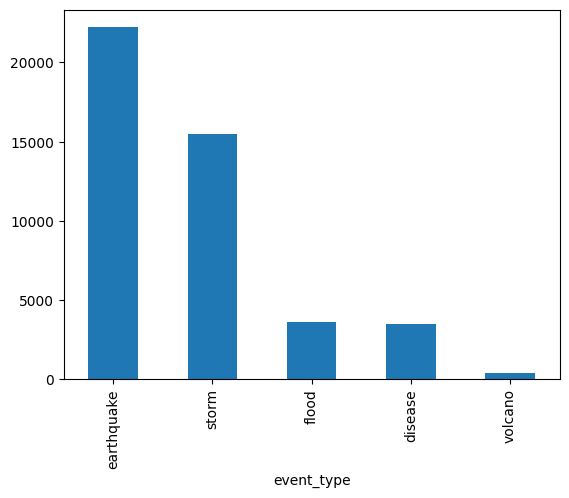

In [39]:
df_non_dupl['event_type'].value_counts().plot(kind='bar')

<Axes: xlabel='relevant'>

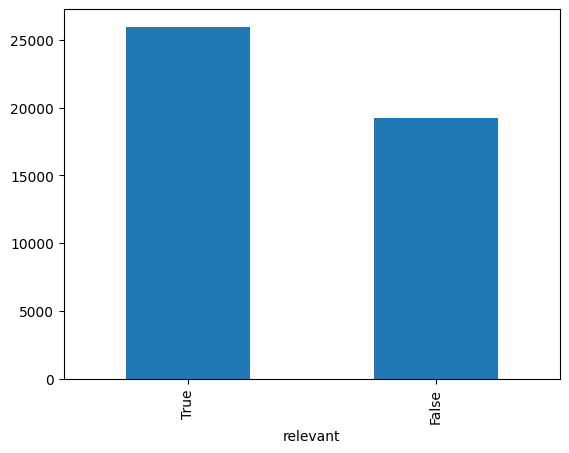

In [40]:
df_non_dupl['relevant'].value_counts().plot(kind='bar')